# Explorar datos con Python — visualizar datos

En este cuaderno aplicaremos algunas técnicas para analizar datos con estadística básica y visualizarlos con gráficos.

## Cargar los datos

Antes de empezar, carguemos los mismos datos de horas de estudio que analizamos en el cuaderno anterior (`grades.csv`, ya disponible en `../datasets/`). También volveremos a calcular quién aprobó la clase, igual que la última vez.

Ejecuta la siguiente celda para cargar los datos del archivo en un DataFrame.

In [1]:
import pandas as pd

# Cargar los datos desde un archivo de texto
df_students = pd.read_csv('../datasets/grades.csv',delimiter=',',header='infer')

# Eliminar las filas con datos faltantes
df_students = df_students.dropna(axis=0, how='any')

# Calcular quién aprobó, asumiendo que '60' es la calificación mínima para aprobar
passes  = pd.Series(df_students['Grade'] >= 60)

# Guardar el resultado en el DataFrame de Pandas
df_students = pd.concat([df_students, passes.rename("Pass")], axis=1)


# Imprimir el resultado en este cuaderno
print(df_students)

         Name  StudyHours  Grade   Pass
0         Dan       10.00   50.0  False
1       Joann       11.50   50.0  False
2       Pedro        9.00   47.0  False
3       Rosie       16.00   97.0   True
4       Ethan        9.25   49.0  False
5       Vicky        1.00    3.0  False
6    Frederic       11.50   53.0  False
7      Jimmie        9.00   42.0  False
8      Rhonda        8.50   26.0  False
9    Giovanni       14.50   74.0   True
10  Francesca       15.50   82.0   True
11      Rajab       13.75   62.0   True
12    Naiyana        9.00   37.0  False
13       Kian        8.00   15.0  False
14      Jenny       15.50   70.0   True
15     Jakeem        8.00   27.0  False
16     Helena        9.00   36.0  False
17      Ismat        6.00   35.0  False
18      Anila       10.00   48.0  False
19       Skye       12.00   52.0  False
20     Daniel       12.50   63.0   True
21      Aisha       12.00   64.0   True


## Visualizar datos con Matplotlib

Los DataFrames son una forma excelente de explorar y analizar datos tabulares, pero a veces una imagen vale más que mil filas y columnas. La biblioteca **Matplotlib** es la base para crear visualizaciones de datos que pueden mejorar mucho tu capacidad de análisis.

Empecemos con un gráfico de barras simple que muestre la calificación de cada estudiante.

**Nota**: Este primer gráfico puede tardar uno o dos minutos en renderizarse. Los siguientes se renderizarán más rápido.

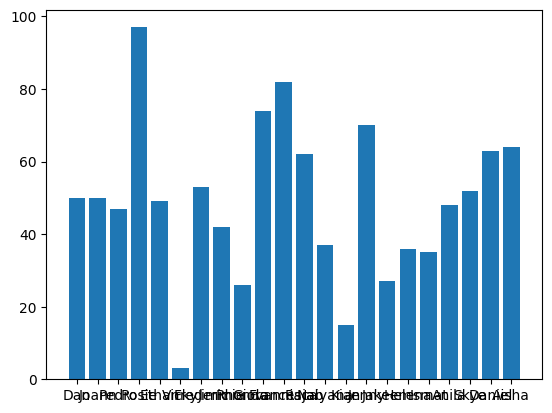

In [2]:
from matplotlib import pyplot as plt

# Crear un gráfico de barras de nombre vs calificación
plt.bar(x=df_students.Name, height=df_students.Grade)

# Mostrar el gráfico
plt.show()

Bien, funcionó, pero el gráfico podría mejorar para que se entienda mejor qué estamos viendo.

Fíjate que usaste la clase **pyplot** de Matplotlib para graficar. Esta clase ofrece muchas formas de mejorar los elementos visuales del gráfico. Por ejemplo, el siguiente código:

- Especifica el color del gráfico de barras.
- Agrega un título al gráfico (para saber qué representa).
- Agrega etiquetas a los ejes X e Y (para saber qué muestra cada eje).
- Agrega una cuadrícula (para leer más fácilmente los valores de las barras).
- Rota las marcas del eje X (para poder leerlas).

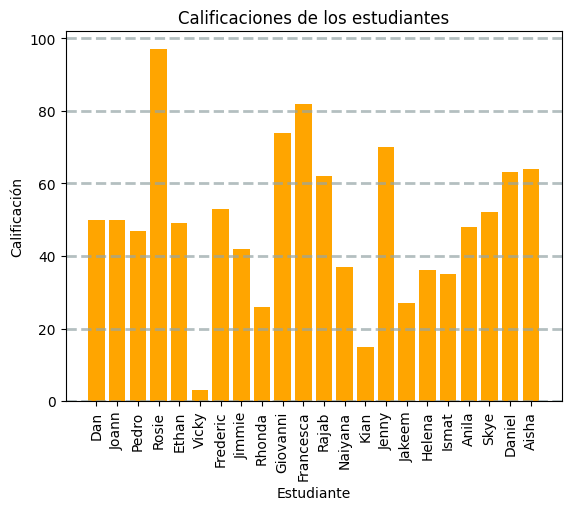

In [3]:
# Crear un gráfico de barras de nombre vs calificación
plt.bar(x=df_students.Name, height=df_students.Grade, color='orange')

# Personalizar el gráfico
plt.title('Calificaciones de los estudiantes')
plt.xlabel('Estudiante')
plt.ylabel('Calificación')
plt.grid(color='#95a5a6', linestyle='--', linewidth=2, axis='y', alpha=0.7)
plt.xticks(rotation=90)

# Mostrar el gráfico
plt.show()

Un gráfico técnicamente está contenido dentro de una **Figure** (figura). En los ejemplos anteriores, la figura se creó implícitamente, pero también puedes crearla de forma explícita. Por ejemplo, el siguiente código crea una figura con un tamaño específico.

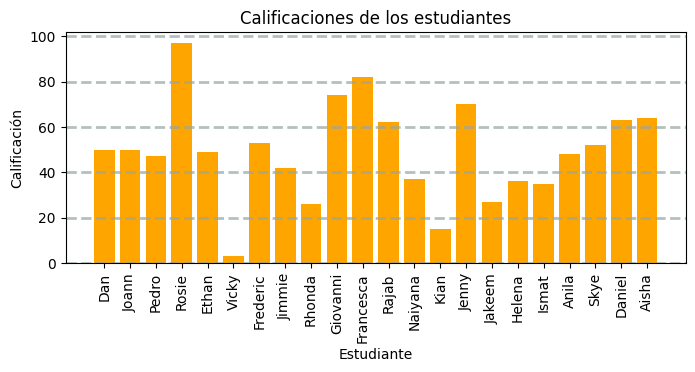

In [4]:
# Crear una figura
fig = plt.figure(figsize=(8,3))

# Crear un gráfico de barras de nombre vs calificación
plt.bar(x=df_students.Name, height=df_students.Grade, color='orange')

# Personalizar el gráfico
plt.title('Calificaciones de los estudiantes')
plt.xlabel('Estudiante')
plt.ylabel('Calificación')
plt.grid(color='#95a5a6', linestyle='--', linewidth=2, axis='y', alpha=0.7)
plt.xticks(rotation=90)

# Mostrar la figura
plt.show()

Una figura puede contener varios subgráficos (subplots), cada uno en su propio *eje* (axis).

Por ejemplo, el siguiente código crea una figura con dos subgráficos: uno es un gráfico de barras con las calificaciones de los estudiantes, y el otro es un gráfico circular que compara la cantidad de calificaciones aprobatorias frente a las no aprobatorias.

C:\Users\migue\AppData\Local\Temp\ipykernel_41968\144704443.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(df_students.Name, rotation=90)
C:\Users\migue\AppData\Local\Temp\ipykernel_41968\144704443.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


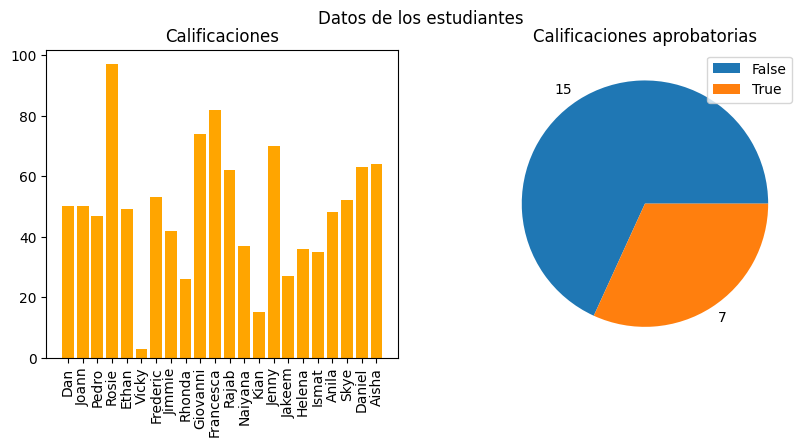

In [5]:
# Crear una figura para 2 subgráficos (1 fila, 2 columnas)
fig, ax = plt.subplots(1, 2, figsize = (10,4))

# Crear un gráfico de barras de nombre vs calificación en el primer eje
ax[0].bar(x=df_students.Name, height=df_students.Grade, color='orange')
ax[0].set_title('Calificaciones')
ax[0].set_xticklabels(df_students.Name, rotation=90)

# Crear un gráfico circular con el conteo de aprobados en el segundo eje
pass_counts = df_students['Pass'].value_counts()
ax[1].pie(pass_counts, labels=pass_counts)
ax[1].set_title('Calificaciones aprobatorias')
ax[1].legend(pass_counts.keys().tolist())

# Agregar un título a la figura
fig.suptitle('Datos de los estudiantes')

# Mostrar la figura
fig.show()

Hasta ahora usaste métodos del objeto `Matplotlib.pyplot` para graficar. Sin embargo, Matplotlib es tan fundamental para los gráficos en Python que muchos paquetes, incluyendo Pandas, ofrecen métodos que abstraen las funciones de Matplotlib subyacentes y simplifican el graficado. Por ejemplo, el DataFrame tiene sus propios métodos para graficar datos, como muestra el siguiente ejemplo, que grafica un gráfico de barras de horas de estudio.

<Axes: xlabel='Name'>

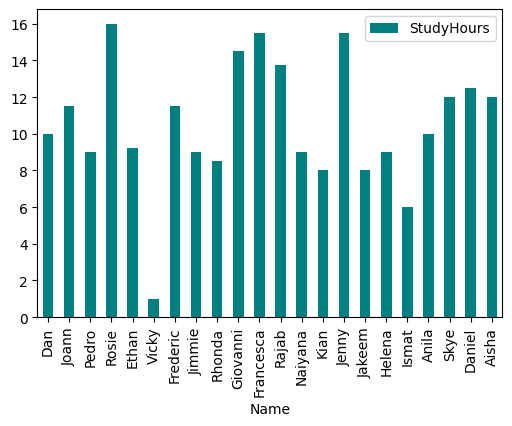

In [6]:
df_students.plot.bar(x='Name', y='StudyHours', color='teal', figsize=(6,4))

## Primeros pasos con el análisis estadístico

Ahora que sabes usar Python para manipular y visualizar datos, puedes empezar a analizarlos.

Buena parte de la ciencia de datos tiene sus raíces en la *estadística*, así que exploraremos algunas técnicas estadísticas básicas.

> **Nota**: Esta sección <u>no</u> pretende enseñarte estadística; ese es un tema demasiado amplio para este cuaderno. Sin embargo, te presentará algunos conceptos y técnicas estadísticas que los científicos de datos usan al explorar datos como preparación para el modelado con Machine Learning.

### Estadística descriptiva y distribución de los datos

Al examinar una *variable* (por ejemplo, una muestra de calificaciones de estudiantes), a los científicos de datos les interesa particularmente su *distribución* (es decir, cómo se reparten los distintos valores de calificación en la muestra). El punto de partida para esta exploración suele ser visualizar los datos como un histograma y ver con qué frecuencia aparece cada valor de la variable.

C:\Users\migue\AppData\Local\Temp\ipykernel_41968\2887123924.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


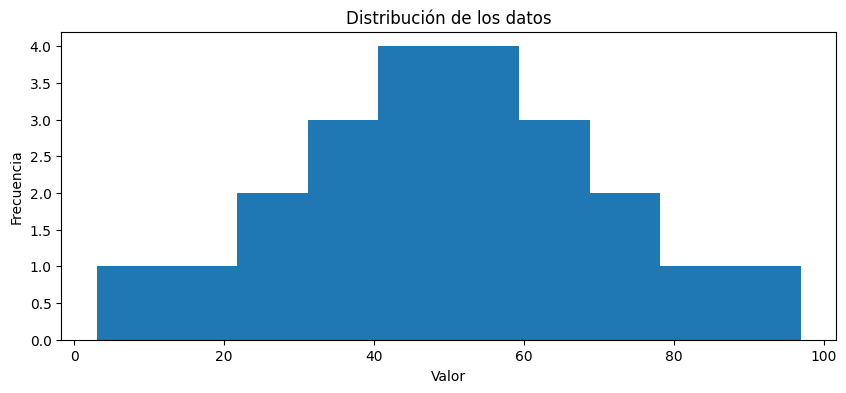

In [7]:
# Obtener la variable a examinar
var_data = df_students['Grade']

# Crear una figura
fig = plt.figure(figsize=(10,4))

# Graficar un histograma
plt.hist(var_data)

# Agregar títulos y etiquetas
plt.title('Distribución de los datos')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')

# Mostrar la figura
fig.show()

El histograma de las calificaciones tiene una forma simétrica, donde las calificaciones más frecuentes tienden a estar en la mitad del rango (alrededor de 50), con menos calificaciones en los extremos de la escala.

**Medidas de tendencia central**

Para entender mejor la distribución, podemos examinar las llamadas *medidas de tendencia central*, una forma elegante de describir estadísticas que representan el "centro" de los datos. El objetivo de este análisis es encontrar un valor "típico". Las formas comunes de definir el centro de los datos son:

- La *media*: un promedio simple, resultado de sumar todos los valores de la muestra y dividir el total entre el número de muestras.
- La *mediana*: el valor que queda justo en el medio del rango de todos los valores de la muestra.
- La *moda*: el valor que aparece con más frecuencia en el conjunto de muestras<sup>+</sup>.

Calculemos estos valores, junto con el mínimo y el máximo para comparar, y mostrémoslos sobre el histograma.

> <sup>+</sup>Por supuesto, en algunos conjuntos de muestras puede haber un empate por el valor más común. En esos casos, el dataset se describe como *bimodal* o incluso *multimodal*.

Mínimo:3.00
Media:49.18
Mediana:49.50
Moda:50.00
Máximo:97.00



C:\Users\migue\AppData\Local\Temp\ipykernel_41968\1210162791.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


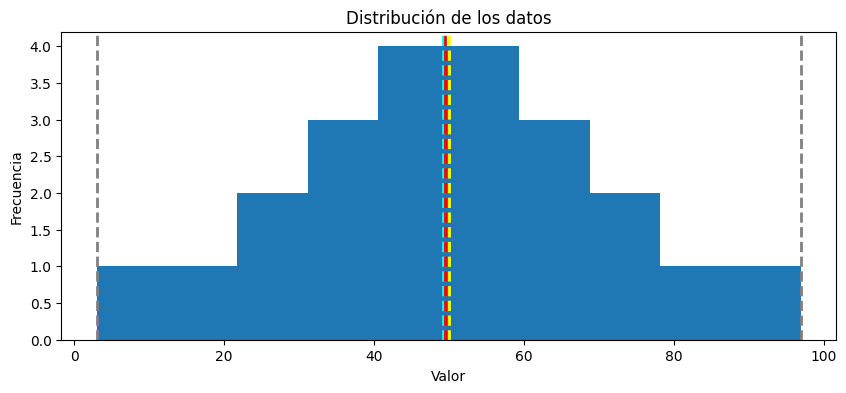

In [8]:
# Obtener la variable a examinar
var = df_students['Grade']

# Obtener las estadísticas
min_val = var.min()
max_val = var.max()
mean_val = var.mean()
med_val = var.median()
mod_val = var.mode()[0]

print('Mínimo:{:.2f}\nMedia:{:.2f}\nMediana:{:.2f}\nModa:{:.2f}\nMáximo:{:.2f}\n'.format(min_val,
                                                                                        mean_val,
                                                                                        med_val,
                                                                                        mod_val,
                                                                                        max_val))

# Crear una figura
fig = plt.figure(figsize=(10,4))

# Graficar un histograma
plt.hist(var)

# Agregar líneas para las estadísticas
plt.axvline(x=min_val, color = 'gray', linestyle='dashed', linewidth = 2)
plt.axvline(x=mean_val, color = 'cyan', linestyle='dashed', linewidth = 2)
plt.axvline(x=med_val, color = 'red', linestyle='dashed', linewidth = 2)
plt.axvline(x=mod_val, color = 'yellow', linestyle='dashed', linewidth = 2)
plt.axvline(x=max_val, color = 'gray', linestyle='dashed', linewidth = 2)

# Agregar títulos y etiquetas
plt.title('Distribución de los datos')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')

# Mostrar la figura
fig.show()

Para los datos de calificaciones, la media, la mediana y la moda parecen estar más o menos en el medio entre el mínimo y el máximo, alrededor de 50.

Otra forma de visualizar la distribución de una variable es con un diagrama de *caja* (o *caja y bigotes*). Creemos uno para los datos de calificaciones.

C:\Users\migue\AppData\Local\Temp\ipykernel_41968\186578474.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


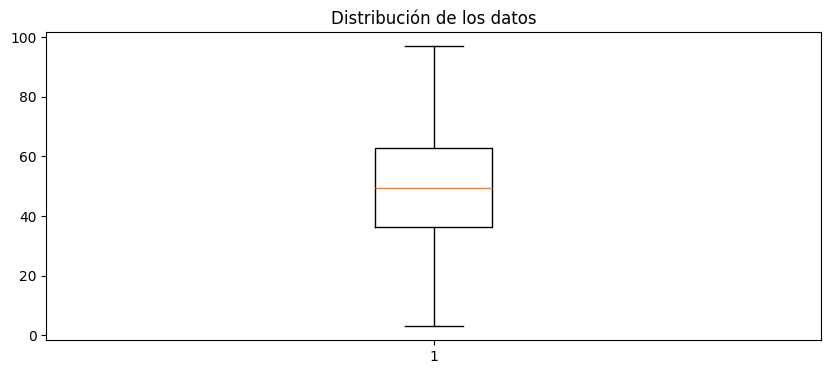

In [9]:
# Obtener la variable a examinar
var = df_students['Grade']

# Crear una figura
fig = plt.figure(figsize=(10,4))

# Graficar un diagrama de caja
plt.boxplot(var)

# Agregar título
plt.title('Distribución de los datos')

# Mostrar la figura
fig.show()

El diagrama de caja muestra la distribución de las calificaciones de una forma distinta al histograma. La parte de la *caja* muestra dónde se ubican los dos *cuartiles* internos de los datos. En este caso, la mitad de las calificaciones están entre aproximadamente 36 y 63. Los *bigotes* que salen de la caja muestran los otros dos cuartiles, así que la otra mitad de las calificaciones está entre 0 y 36, o entre 63 y 100. La línea dentro de la caja indica el valor de la *mediana*.

Para aprender, es útil combinar histogramas y diagramas de caja, cambiando la orientación del diagrama de caja para alinearlo con el histograma. (En cierto modo, ayuda pensar en el histograma como una vista "de frente" de la distribución, y en el diagrama de caja como una vista "de planta" de la distribución vista desde arriba).

Mínimo:3.00
Media:49.18
Mediana:49.50
Moda:50.00
Máximo:97.00



C:\Users\migue\AppData\Local\Temp\ipykernel_41968\162207614.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


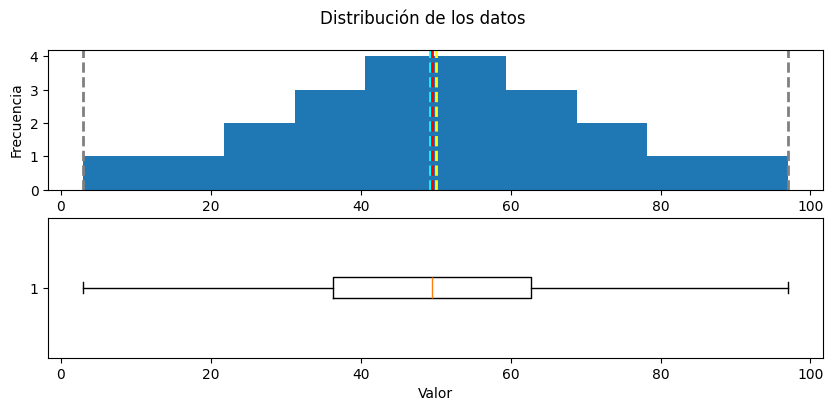

In [10]:
# Crear una función que podamos reutilizar
def mostrar_distribucion(var_data):
    from matplotlib import pyplot as plt

    # Obtener las estadísticas
    min_val = var_data.min()
    max_val = var_data.max()
    mean_val = var_data.mean()
    med_val = var_data.median()
    mod_val = var_data.mode()[0]

    print('Mínimo:{:.2f}\nMedia:{:.2f}\nMediana:{:.2f}\nModa:{:.2f}\nMáximo:{:.2f}\n'.format(min_val,
                                                                                            mean_val,
                                                                                            med_val,
                                                                                            mod_val,
                                                                                            max_val))

    # Crear una figura para 2 subgráficos (2 filas, 1 columna)
    fig, ax = plt.subplots(2, 1, figsize = (10,4))

    # Graficar el histograma
    ax[0].hist(var_data)
    ax[0].set_ylabel('Frecuencia')

    # Agregar líneas para la media, mediana y moda
    ax[0].axvline(x=min_val, color = 'gray', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=mean_val, color = 'cyan', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=med_val, color = 'red', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=mod_val, color = 'yellow', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=max_val, color = 'gray', linestyle='dashed', linewidth = 2)

    # Graficar el diagrama de caja
    ax[1].boxplot(var_data, vert=False)
    ax[1].set_xlabel('Valor')

    # Agregar un título a la figura
    fig.suptitle('Distribución de los datos')

    # Mostrar la figura
    fig.show()

# Obtener la variable a examinar
col = df_students['Grade']
# Llamar a la función
mostrar_distribucion(col)

Todas las medidas de tendencia central están justo en el medio de la distribución de los datos, que es simétrica, con valores que van bajando progresivamente en ambas direcciones desde el centro.

Para explorar esta distribución con más detalle, hay que entender que la estadística se trata fundamentalmente de tomar *muestras* de datos y usar funciones de probabilidad para extrapolar información sobre la *población* completa de datos.

¿Qué significa esto? Las *muestras* son los datos que tenemos a mano, como la información sobre los hábitos de estudio y calificaciones de estos 22 estudiantes. La *población* se refiere a todos los datos posibles que podríamos recolectar, como las calificaciones y hábitos de estudio de cada estudiante en cada institución educativa a lo largo de toda la historia. Normalmente nos interesa la población, pero simplemente no es viable recolectar todos esos datos. En su lugar, tenemos que intentar estimar cómo es la población a partir de la pequeña cantidad de datos (muestras) que tenemos.

Si tenemos suficientes muestras, podemos calcular algo llamado *función de densidad de probabilidad*, que estima la distribución de las calificaciones para toda la población.

La clase **pyplot** de Matplotlib ofrece una función útil para graficar esta densidad.

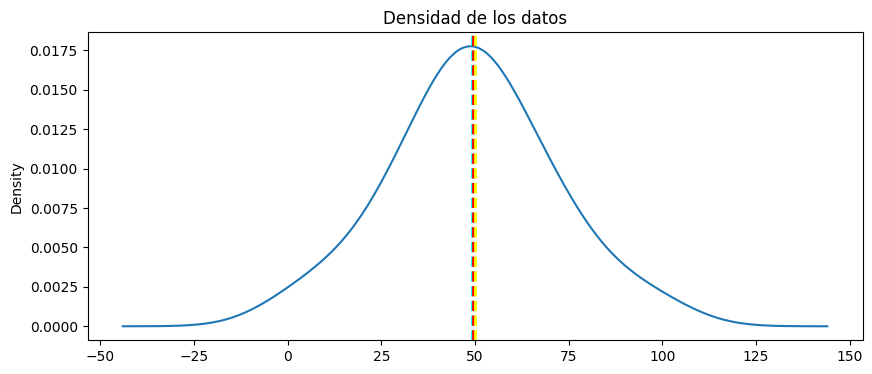

In [11]:
def mostrar_densidad(var_data):
    from matplotlib import pyplot as plt

    fig = plt.figure(figsize=(10,4))

    # Graficar la densidad
    var_data.plot.density()

    # Agregar títulos y etiquetas
    plt.title('Densidad de los datos')

    # Mostrar la media, mediana y moda
    plt.axvline(x=var_data.mean(), color = 'cyan', linestyle='dashed', linewidth = 2)
    plt.axvline(x=var_data.median(), color = 'red', linestyle='dashed', linewidth = 2)
    plt.axvline(x=var_data.mode()[0], color = 'yellow', linestyle='dashed', linewidth = 2)

    # Mostrar la figura
    plt.show()

# Obtener la densidad de Grade
col = df_students['Grade']
mostrar_densidad(col)

Tal como se esperaba a partir del histograma de la muestra, la densidad muestra la característica "curva de campana" de lo que los estadísticos llaman una distribución *normal*, con la media y la moda en el centro y colas simétricas.

## Resumen

¡Bien hecho! Aparecieron varios conceptos nuevos, así que resumamos.

Aquí:

1. Hicimos gráficos con Matplotlib.
2. Aprendimos a personalizar esos gráficos.
3. Calculamos estadísticas básicas, como medianas.
4. Vimos la dispersión de los datos usando diagramas de caja e histogramas.
5. Aprendimos sobre muestras frente a poblaciones.
6. Estimamos cómo podría verse la población de calificaciones a partir de una muestra de calificaciones.